# Sam3 using Sam3 Tracker Predictor

In [1]:
import torch
import numpy as np
import os
import glob
from accelerate import Accelerator
from transformers import Sam3VideoModel, Sam3VideoProcessor
from transformers import Sam3TrackerVideoModel, Sam3TrackerVideoProcessor
from PIL import Image

device = Accelerator().device
model1 = Sam3VideoModel.from_pretrained("facebook/sam3").to(device, dtype=torch.bfloat16)
processor1 = Sam3VideoProcessor.from_pretrained("facebook/sam3", dtype=torch.bfloat16,)
video_path = "./videos/frames"
video_frames_paths = glob.glob(os.path.join(video_path, "*.jpg"))
video_frames_paths.sort(key=lambda p: int(os.path.splitext(os.path.basename(p))[0]))
video_frames = [np.array(Image.open(f)) for f in video_frames_paths]
inference_session1 = processor1.init_video_session(
    video=video_frames,
    inference_device=device,
    processing_device="cpu",
    video_storage_device="cpu",
    dtype=torch.bfloat16,
)
# Add text prompt to detect and track objects
text = "fish"
inference_session1 = processor1.add_text_prompt(
    inference_session=inference_session1,
    text=text,
)
outputs_per_frame1 = {}
for model_outputs in model1.propagate_in_video_iterator(
    inference_session=inference_session1, max_frame_num_to_track=50
):
    processed_outputs1 = processor1.postprocess_outputs(inference_session1, model_outputs)
    outputs_per_frame1[model_outputs.frame_idx] = processed_outputs1

print(f"Processed {len(outputs_per_frame1)} frames")

Loading weights:   0%|          | 0/1797 [00:00<?, ?it/s]

[transformers] kernels library is not installed. NMS post-processing, hole filling, and sprinkle removal will be skipped. Install it with `pip install kernels` for better mask quality.


Processed 5 frames


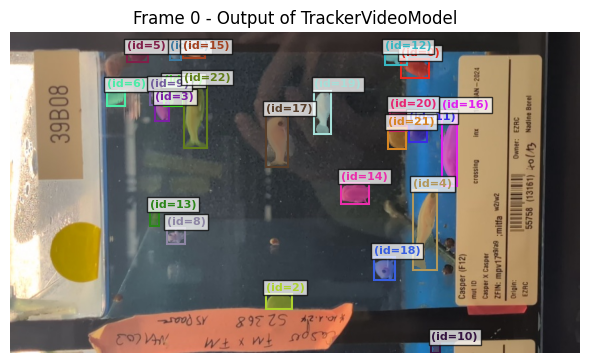

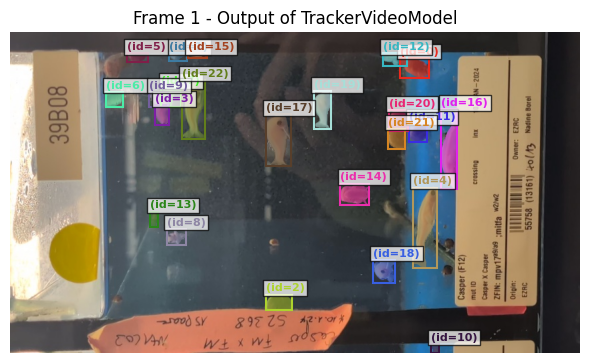

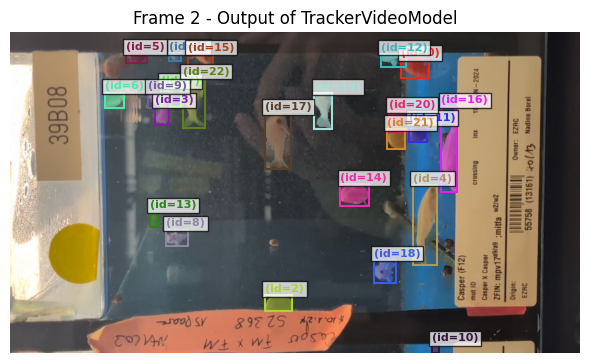

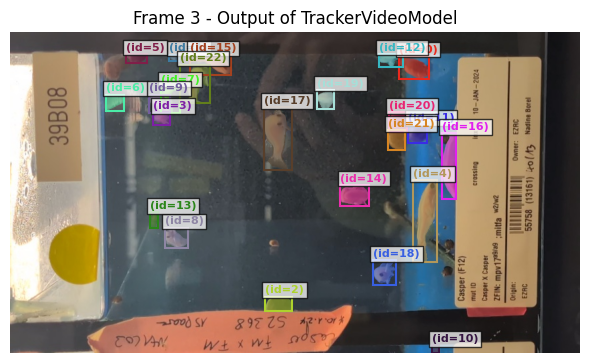

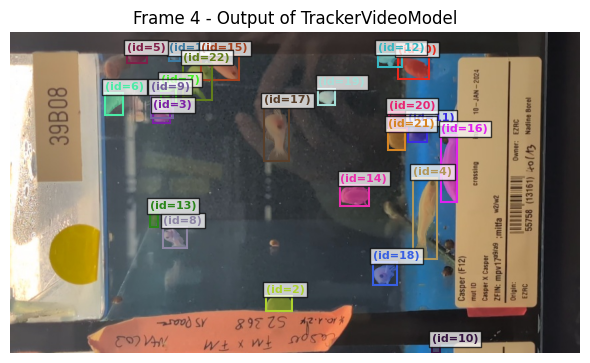

In [2]:
from sam3.visualization_utils import (
    load_frame,
    prepare_masks_for_visualization,
    visualize_formatted_frame_output,
)


outputs_new_format1 = []

for frame in range(0, len(outputs_per_frame1)):
    frame_data = {}
    frame_data['out_obj_ids'] = outputs_per_frame1[frame]['object_ids'].cpu()
    frame_data['out_boxes_xywh'] = outputs_per_frame1[frame]['boxes'].cpu()
    frame_data['out_binary_masks'] = outputs_per_frame1[frame]['masks'].cpu()
    
    outputs_new_format1.append(frame_data)

for frame_idx in range(0, len(outputs_new_format1)):
    visualize_formatted_frame_output(
        frame_idx,
        video_frames,
        outputs_list=[prepare_masks_for_visualization({frame_idx: outputs_new_format1[frame_idx]})],
        titles=["Output of TrackerVideoModel"],
        figsize=(6, 4),
    )

# Part 2: Use Sam3TrackerPredictor

In [3]:
import torch
import glob
import os

import cv2
import matplotlib.pyplot as plt
import numpy as np

import sam3
import torch
from PIL import Image
from sam3.visualization_utils import show_box, show_mask, show_points

video_path = "./videos/frames"



if device.type == "cuda":
    # use bfloat16 for the entire notebook
    torch.autocast("cuda", dtype=torch.bfloat16).__enter__()
    # turn on tfloat32 for Ampere GPUs (https://pytorch.org/docs/stable/notes/cuda.html#tensorfloat-32-tf32-on-ampere-devices)
    print("device is cuda")



device is cuda


In [4]:
import torch
from sam3.model_builder import build_sam3_video_model

bpe_path = "./sam3/sam3/assets/bpe_simple_vocab_16e6.txt.gz"

# 1. Modell laden
sam3_model2 = build_sam3_video_model(bpe_path=bpe_path, device=device)

# 2. Das gesamte Modell auf FP16 (Half) und CUDA umstellen
sam3_model2 = sam3_model2.half().cuda() 

# 3. Jetzt erst die Predictor-Referenzen setzen
# Da sam3_model2 jetzt FP16 ist, sind auch tracker und backbone automatisch FP16
predictor2 = sam3_model2.tracker
predictor2.backbone = sam3_model2.detector.backbone

print(f"Predictor läuft auf: {next(sam3_model2.parameters()).dtype}") 
# Sollte torch.float16 ausgeben

/mnt/c/Users/sinke/Desktop/Masterarbeit/sam3/sam3/sam3/model/model_misc.py:70: UserWarning: Flash Attention is disabled as it requires a GPU with Ampere (8.0) CUDA capability.
  OLD_GPU, USE_FLASH_ATTN, MATH_KERNEL_ON = get_sdpa_settings()
/home/xxbananaopxx/anaconda3/envs/ma1/lib/python3.12/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
INFO 2026-06-08 08:12:33,284 710 sam3_video_base.py: 348: setting max_num_objects=10000 and num_obj_for_compile=16


Predictor läuft auf: torch.float16


In [5]:
outputs_per_frame1[0].keys()

dict_keys(['object_ids', 'scores', 'boxes', 'masks', 'prompt_to_obj_ids'])

In [6]:
inference_state2 = predictor2.init_state(
    video_path=video_path,
    offload_video_to_cpu=True, # Video-Bilder bleiben im RAM
    offload_state_to_cpu=True   # Gedächtnis-Tokens bleiben im RAM
)

frame loading (JPEG): 100%|███████████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 56.76it/s]


### Now we test what happens in the first iteration and if the boxes are transferred and the right masks are generated

In [11]:
import torch
frame_idx_test=0
# 1. Sicherstellen, dass das Device korrekt definiert ist
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

img_h, img_w = video_frames[0].shape[:2]

object_ids = outputs_per_frame1[frame_idx_test]['object_ids']
boxes = outputs_per_frame1[frame_idx_test]['boxes']

# 2. Die Box vorbereiten (auf GPU und FP16)
for i, object_id in enumerate(object_ids):
    orig_box = boxes[i].to(device) # [x1, y1, x2, y2]
    norm_box = orig_box.clone().float()
    norm_box[0] /= img_w  # x1
    norm_box[2] /= img_w  # x2
    norm_box[1] /= img_h  # y1
    norm_box[3] /= img_h  # y2
    
    # 3. Dummy-Tensoren für Punkte und Labels auf der GPU erstellen
    # Diese überschreiben die CPU-Standardwerte der Funktion
    # Points: [Batch, Anzahl, XY] -> [1, 0, 2]
    # Labels: [Batch, Anzahl]     -> [1, 0]
    empty_points = torch.zeros((1, 0, 2), device=device, dtype=torch.float16)
    empty_labels = torch.zeros((1, 0), device=device, dtype=torch.int32)
    
    # 4. Der Aufruf mit allen drei Komponenten auf dem richtigen Device
    _, out_obj_ids, low_res_masks, video_res_masks = predictor2.add_new_points_or_box(
        inference_state=inference_state2,
        frame_idx=frame_idx_test,
        obj_id=int(object_ids[i]),
        box=norm_box,         # Auf CUDA
        points=empty_points,       # Auf CUDA
        labels=empty_labels,        # Auf CUDA
        
    )
    
    print("Inferenz erfolgreich!")
    if video_res_masks is not None:
        print(f"Maske generiert mit Max-Wert: {video_res_masks.max().item()}")

Inferenz erfolgreich!
Maske generiert mit Max-Wert: 26.41427230834961
Inferenz erfolgreich!
Maske generiert mit Max-Wert: 27.664491653442383
Inferenz erfolgreich!
Maske generiert mit Max-Wert: 27.664491653442383
Inferenz erfolgreich!
Maske generiert mit Max-Wert: 27.664491653442383
Inferenz erfolgreich!
Maske generiert mit Max-Wert: 27.664491653442383
Inferenz erfolgreich!
Maske generiert mit Max-Wert: 27.664491653442383
Inferenz erfolgreich!
Maske generiert mit Max-Wert: 27.664491653442383
Inferenz erfolgreich!
Maske generiert mit Max-Wert: 27.664491653442383
Inferenz erfolgreich!
Maske generiert mit Max-Wert: 27.664491653442383
Inferenz erfolgreich!
Maske generiert mit Max-Wert: 27.664491653442383
Inferenz erfolgreich!
Maske generiert mit Max-Wert: 29.316532135009766
Inferenz erfolgreich!
Maske generiert mit Max-Wert: 29.316532135009766
Inferenz erfolgreich!
Maske generiert mit Max-Wert: 29.316532135009766
Inferenz erfolgreich!
Maske generiert mit Max-Wert: 29.316532135009766
Inferen

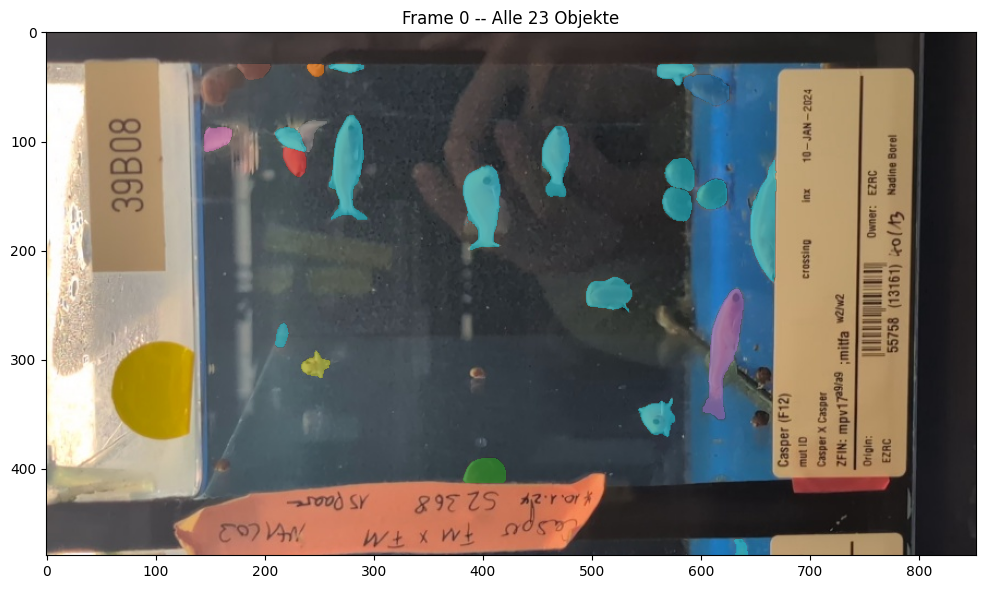

In [8]:
plt.figure(figsize=(12, 8))
plt.title(f"Frame 0 -- Alle {len(out_obj_ids)} Objekte")
plt.imshow(video_frames[0])

# 1. Masken auf die CPU holen und binarisieren
masks_np = (video_res_masks > 0.0).cpu().numpy()

# 2. Durch alle Objekte loopen und show_mask einzeln aufrufen
for i in range(len(out_obj_ids)):
    # Wir nehmen nur die i-te Maske: masks_np[i]
    # obj_id=out_obj_ids[i] sorgt dafür, dass jeder Fisch seine eigene Farbe behält
    show_mask(masks_np[i], plt.gca(), obj_id=out_obj_ids[i])

plt.show()

### PURPOSE FOR DBUGGING ONLY (testing if the boxes are correct)

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import torch
import numpy as np

def debug_plot_box(frame_idx, box_tensor, video_frames, title="Box Check"):
    """
    Zeigt einen Video-Frame und zeichnet die übergebene Box ein.
    """
    # 1. Bild holen
    # Falls video_frames eine Liste von Pfaden ist:
    if isinstance(video_frames[frame_idx], str):
        img = Image.open(video_frames[frame_idx])
        img_w, img_h = img.size
    else:
        # Falls es bereits ein Array/Tensor ist
        img = video_frames[frame_idx]
        if hasattr(img, 'shape'):
            img_h, img_w = img.shape[:2]
        else:
            img_w, img_h = img.size

    # 2. Box-Koordinaten vorbereiten (auf CPU und in Liste umwandeln)
    box = box_tensor.cpu().float().tolist()
    x1, y1, x2, y2 = box
    
    fig, ax = plt.subplots(figsize=(12, 8))
    ax.imshow(img)
    
    # 3. Das Rechteck erstellen
    # Achtung: matplotlib Rectangle braucht (x, y, breite, höhe)
    width = x2 - x1
    height = y2 - y1
    
    rect = patches.Rectangle(
        (x1, y1), width, height, 
        linewidth=2, edgecolor='r', facecolor='none', label='Übergebene Box'
    )
    
    # 4. Box hinzufügen
    ax.add_patch(rect)
    
    # 5. Anzeige-Informationen
    plt.title(f"{title} - Frame {frame_idx}\nBox: {box}\nBildgröße: {img_w}x{img_h}")
    plt.legend()
    
    # Falls die Box extrem klein oder außerhalb ist, Achsen anpassen
    plt.axvline(x=x1, color='r', linestyle='--', alpha=0.3)
    plt.axhline(y=y1, color='r', linestyle='--', alpha=0.3)
    
    plt.show()

# --- TESTAUFRUF ---
debug_plot_box(0, current_box, video_frames)

### Give our tracker model all box outputs from the previous model (optional)

In [12]:
for frame in range(frame_idx_test+1, len(video_frames)):
    object_ids = outputs_per_frame1[frame]['object_ids']
    boxes = outputs_per_frame1[frame]['boxes']

    for i, object_id in enumerate(object_ids):
        orig_box = boxes[i].to(device) # [x1, y1, x2, y2]
        norm_box = orig_box.clone().float()
        norm_box[0] /= img_w  # x1
        norm_box[2] /= img_w  # x2
        norm_box[1] /= img_h  # y1
        norm_box[3] /= img_h  # y2
        
        # 3. Dummy-Tensoren für Punkte und Labels auf der GPU erstellen
        # Diese überschreiben die CPU-Standardwerte der Funktion
        # Points: [Batch, Anzahl, XY] -> [1, 0, 2]
        # Labels: [Batch, Anzahl]     -> [1, 0]
        empty_points = torch.zeros((1, 0, 2), device=device, dtype=torch.float16)
        empty_labels = torch.zeros((1, 0), device=device, dtype=torch.int32)
        
        # 4. Der Aufruf mit allen drei Komponenten auf dem richtigen Device
        _, out_obj_ids, low_res_masks, video_res_masks = predictor2.add_new_points_or_box(
            inference_state=inference_state2,
            frame_idx=frame,
            obj_id=int(object_ids[i]),
            box=norm_box,         # Auf CUDA
            points=empty_points,       # Auf CUDA
            labels=empty_labels,        # Auf CUDA
            )

In [13]:
video_segments = {}  # video_segments contains the per-frame segmentation results
for frame_idx, obj_ids, low_res_masks, video_res_masks, obj_scores in predictor2.propagate_in_video(inference_state2, start_frame_idx=0, max_frame_num_to_track=240, reverse=False, propagate_preflight=True):
    print("in loop")
    video_segments[frame_idx] = {
        out_obj_id: (video_res_masks[i] > 0.0).cpu().numpy()
        for i, out_obj_id in enumerate(outputs_per_frame1[frame_idx]['object_ids'])
    }

propagate in video:   0%|          | 0/5 [00:00<?, ?it/s]

in loop
in loop
in loop
in loop
in loop


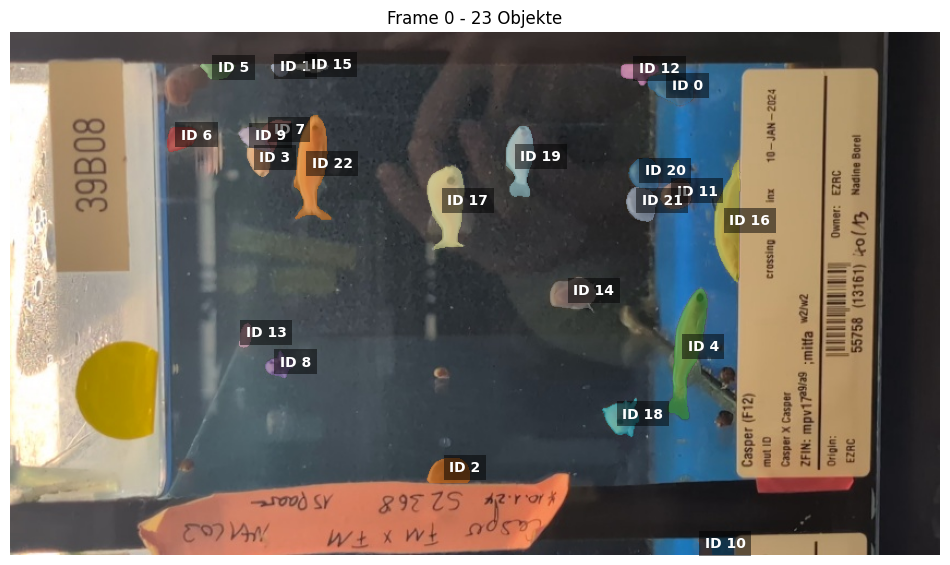

In [14]:
import matplotlib.pyplot as plt
import importlib
importlib.reload(plt) # Stellt das originale plt.show wieder her

import cv2 # Für schnelles Resizing
import numpy as np
import torch

def show_frame_with_segments_fixed(frame_idx, video_segments, video_frames):
    img = video_frames[frame_idx]
    frame_masks = video_segments[frame_idx]
    
    h, w = img.shape[:2] # Die Größe des echten Bildes
    
    plt.figure(figsize=(12, 8))
    plt.imshow(img)
    
    if not frame_masks:
        print(f"Keine Masken für Frame {frame_idx} gefunden.")
        plt.show()
        return

    cmap = plt.get_cmap("tab20") 

    for i, (obj_id, mask_data) in enumerate(frame_masks.items()):
        # 1. Daten zu Numpy
        if torch.is_tensor(mask_data):
            mask = mask_data.cpu().detach().numpy()
        else:
            mask = mask_data
            
        if mask.ndim == 3:
            mask = mask[0]

        # 2. Skalierung: Wenn die Maske kleiner ist als das Bild, hochskalieren
        if mask.shape != (h, w):
            mask = cv2.resize(mask.astype(float), (w, h), interpolation=cv2.INTER_LINEAR)
            
        # 3. Binarisierung (Schwellenwert)
        # Probier mal 0.0. Wenn das nichts zeigt, lass dir mask.max() ausgeben
        binary_mask = mask > 0.0 
        
        if not binary_mask.any():
            continue
            
        color = cmap(i % 20)
        overlay = np.zeros((h, w, 4))
        overlay[binary_mask] = [*color[:3], 0.5] # 50% Transparenz
        
        plt.imshow(overlay)
        
        # ID-Text
        coords = np.argwhere(binary_mask)
        if coords.size > 0:
            y, x = coords.mean(axis=0)
            plt.text(x, y, f"ID {obj_id}", color="white", fontsize=10, 
                     fontweight='bold', bbox=dict(facecolor='black', alpha=0.5, edgecolor='none'))

    plt.title(f"Frame {frame_idx} - {len(frame_masks)} Objekte")
    plt.axis('off')
    plt.show()

# Testaufruf
show_frame_with_segments_fixed(0, video_segments, video_frames)

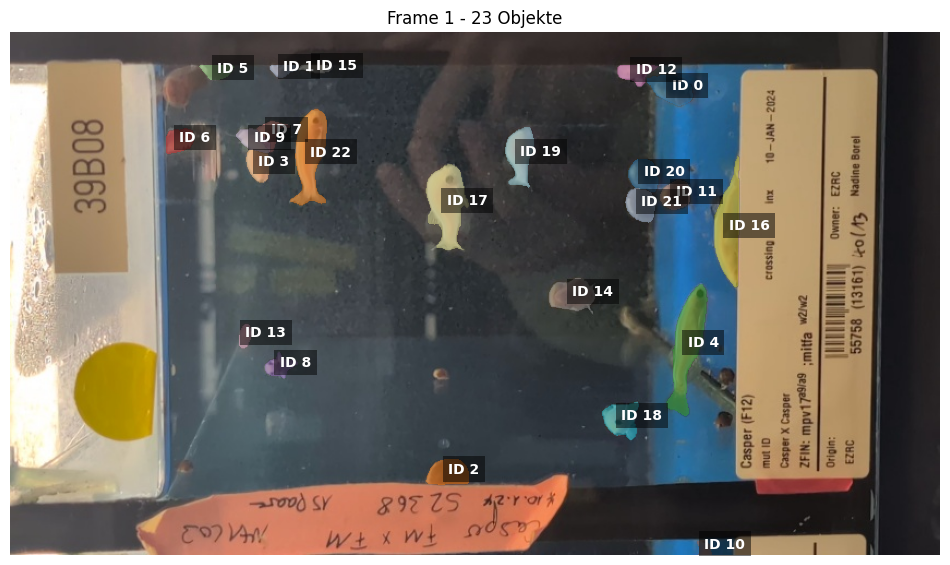

In [15]:
show_frame_with_segments_fixed(1, video_segments, video_frames)

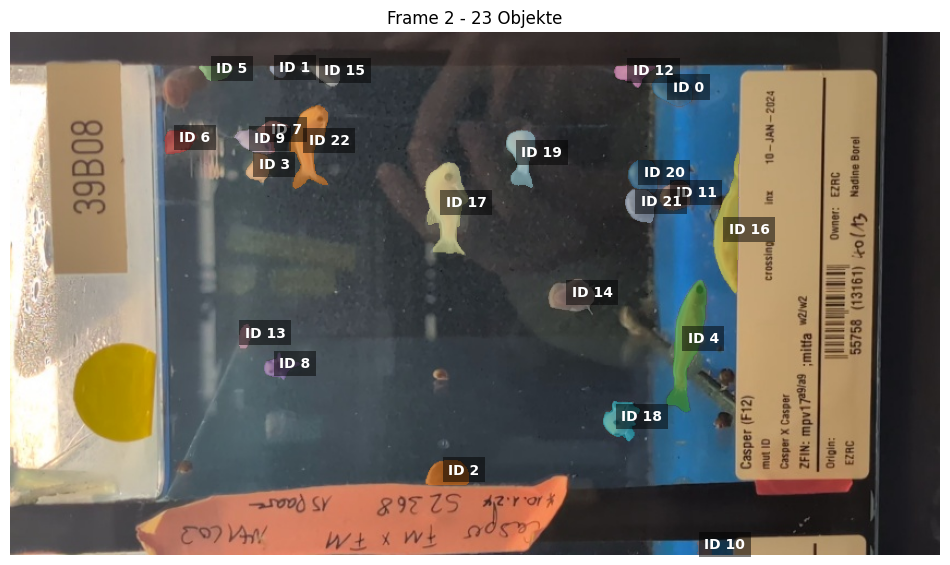

In [16]:
show_frame_with_segments_fixed(2, video_segments, video_frames)

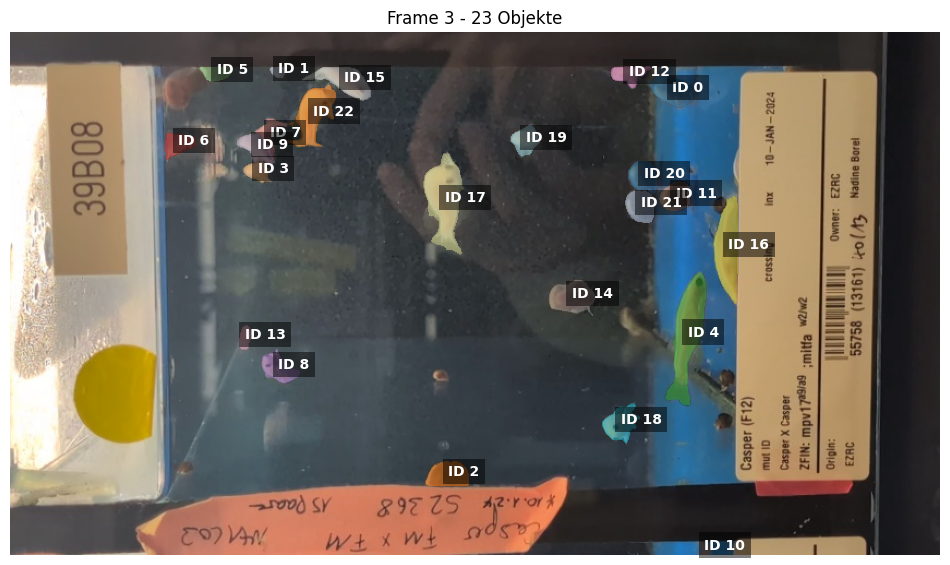

In [17]:
show_frame_with_segments_fixed(3, video_segments, video_frames)

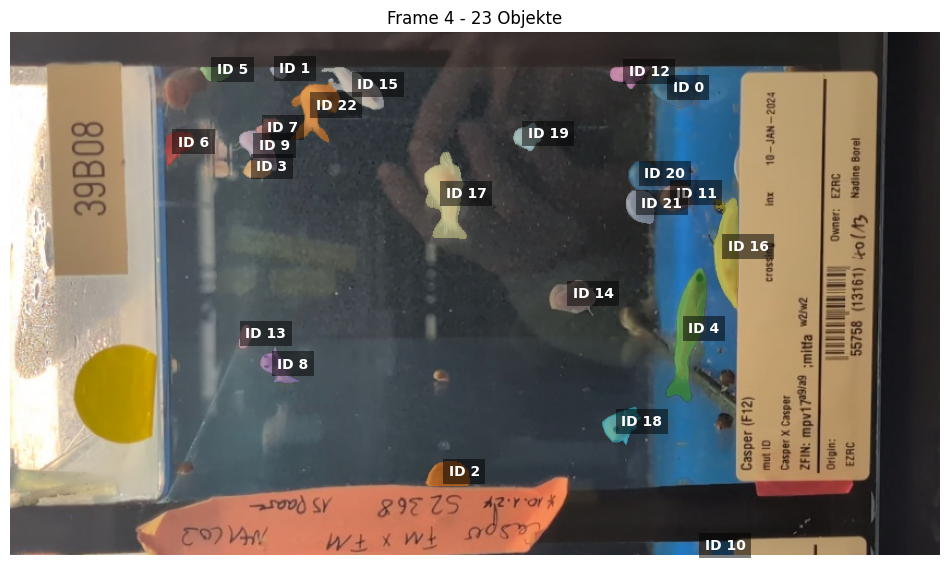

In [18]:
show_frame_with_segments_fixed(4, video_segments, video_frames)

In [16]:
# Part 3: Interactive

In [19]:
video_segments.keys()

dict_keys([0, 1, 2, 3, 4])

In [33]:
outputs_new_format2 = []

print("Starte Tracking...")

for frame_idx, trk_obj_ids, low_res_masks, video_res_masks, obj_scores in predictor2.propagate_in_video(
    inference_state2, 
    start_frame_idx=0, 
    max_frame_num_to_track=240, 
    reverse=False
):
    frame_data = {}
    frame_data['out_obj_ids'] = torch.tensor(trk_obj_ids).cpu()
    
    # DER FIX: .squeeze(1) entfernt die unnötige Kanal-Dimension [23, 1, 480, 853] -> [23, 480, 853]
    binary_masks = (video_res_masks > 0.0).cpu().squeeze(1)
    frame_data['out_binary_masks'] = binary_masks
    
    # Boxen berechnen (für deinen Key out_boxes_xywh)
    calculated_boxes = []
    for i in range(len(binary_masks)):
        mask_np = binary_masks[i].numpy() # Jetzt korrekt [H, W]
        coords = np.argwhere(mask_np)
        if coords.size > 0:
            y_min, x_min = coords.min(axis=0)
            y_max, x_max = coords.max(axis=0)
            calculated_boxes.append([float(x_min), float(y_min), float(x_max - x_min), float(y_max - y_min)])
        else:
            calculated_boxes.append([0, 0, 0, 0])
            
    frame_data['out_boxes_xywh'] = torch.tensor(calculated_boxes)
    outputs_new_format2.append(frame_data)

print("Daten erfolgreich vorbereitet. Du kannst jetzt den Visualisierungs-Loop starten.")

Starte Tracking...


propagate in video:   0%|          | 0/5 [00:00<?, ?it/s]

Daten erfolgreich vorbereitet. Du kannst jetzt den Visualisierungs-Loop starten.


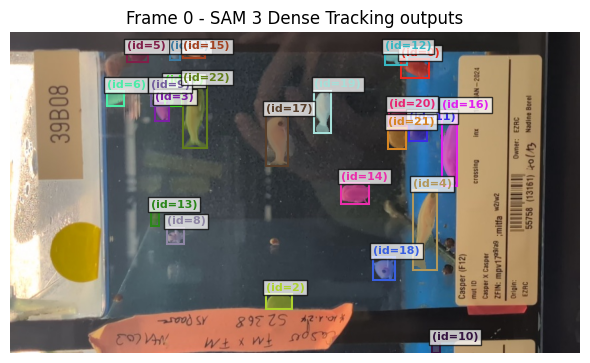

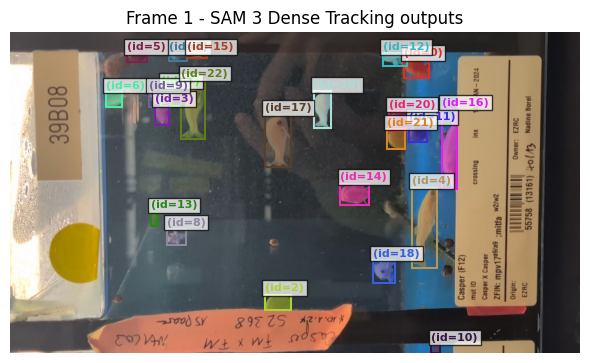

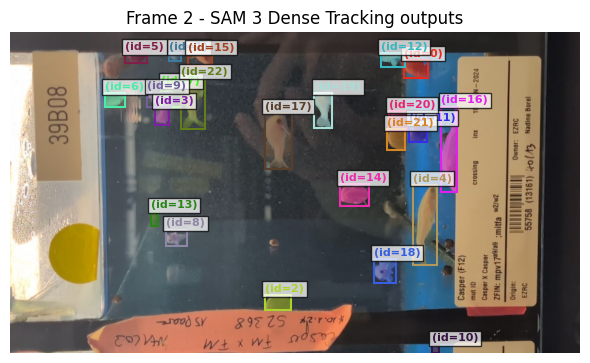

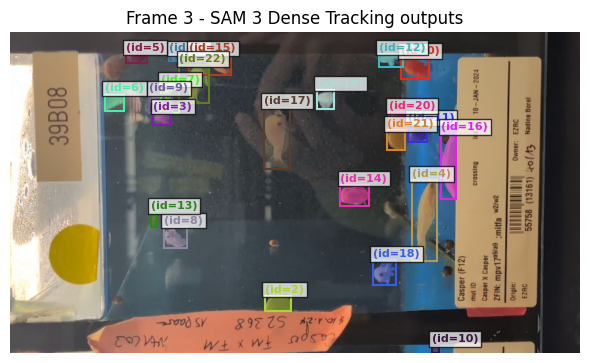

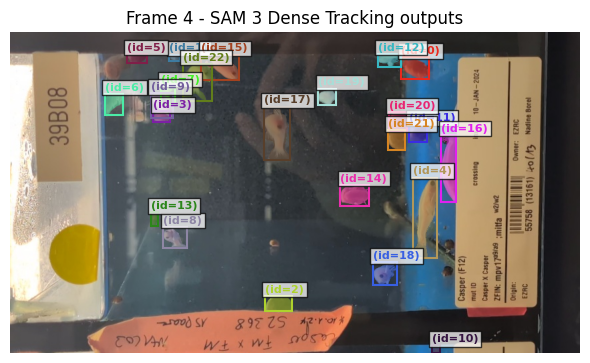

In [34]:
import matplotlib.pyplot as plt

# Wir deaktivieren plt.show kurzzeitig, falls wir nur speichern wollen, 
# oder lassen es an, wenn wir die Plots im Notebook sehen wollen.

for frame_idx in range(0, len(outputs_new_format2)):
    # Speicher für Matplotlib freigeben
    plt.close('all')
    
    # Dein gewünschter Aufruf
    visualize_formatted_frame_output(
        frame_idx,
        video_frames,
        outputs_list=[prepare_masks_for_visualization({frame_idx: outputs_new_format2[frame_idx]})],
        titles=["SAM 3 Dense Tracking outputs"],
        figsize=(6, 4),
    )

Above, we see some objects that are not fish but tracket eg. id = 0

In [20]:
predictor2.clear_all_points_in_video(inference_state2) #reset state

In [21]:
frame_idx_test=0
# 1. Sicherstellen, dass das Device korrekt definiert ist
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

img_h, img_w = video_frames[0].shape[:2]

object_ids = outputs_per_frame1[frame_idx_test]['object_ids']
boxes = outputs_per_frame1[frame_idx_test]['boxes']

# 2. Die Box vorbereiten (auf GPU und FP16)
for i, object_id in enumerate(object_ids):
    orig_box = boxes[i].to(device) # [x1, y1, x2, y2]
    norm_box = orig_box.clone().float()
    norm_box[0] /= img_w  # x1
    norm_box[2] /= img_w  # x2
    norm_box[1] /= img_h  # y1
    norm_box[3] /= img_h  # y2
    
    empty_points = torch.zeros((1, 0, 2), device=device, dtype=torch.float16)
    empty_labels = torch.zeros((1, 0), device=device, dtype=torch.int32)
    
    # 4. Der Aufruf mit allen drei Komponenten auf dem richtigen Device
    _, out_obj_ids, low_res_masks, video_res_masks = predictor2.add_new_points_or_box(
        inference_state=inference_state2,
        frame_idx=frame_idx_test,
        obj_id=int(object_ids[i]),
        box=norm_box,         # Auf CUDA
        points=empty_points,       # Auf CUDA
        labels=empty_labels,        # Auf CUDA
        
    )

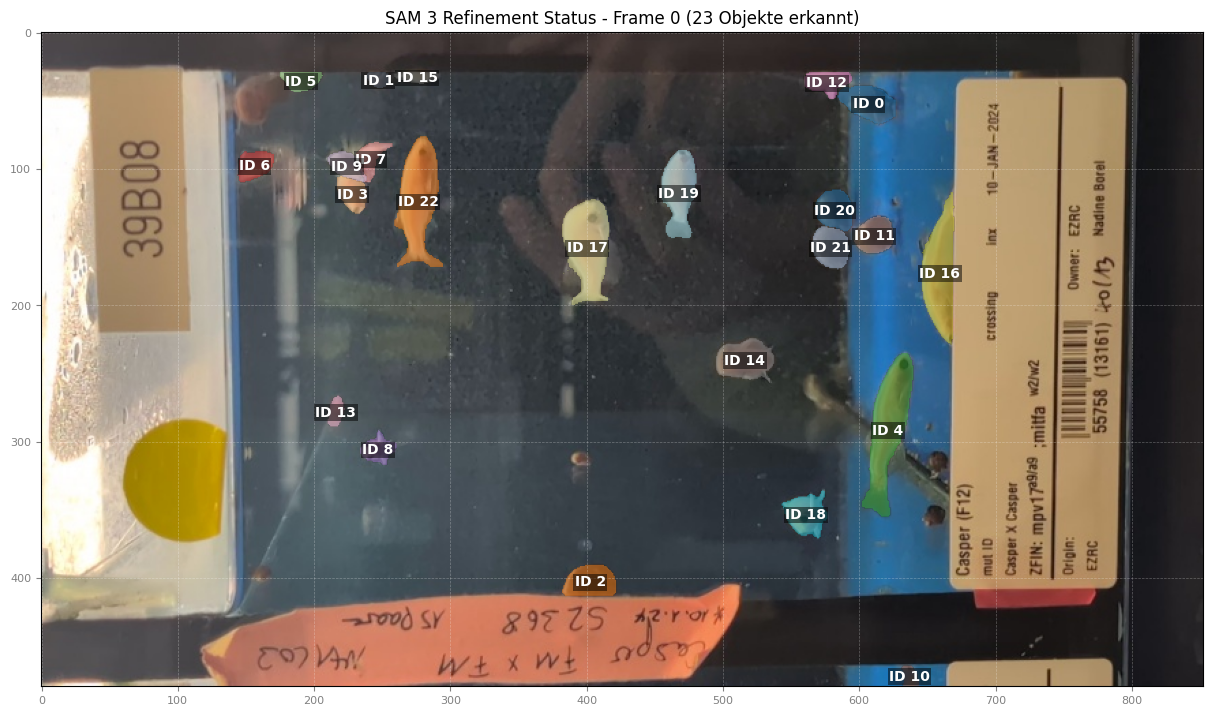

In [22]:
def visualize_current_state(frame_idx, masks, obj_ids, video_frames, title="Refinement Ergebnis"):
    """
    Visualisiert die aktuellen Masken aus dem Inference-State inklusive IDs und Raster.
    """
    # Sicherstellen, dass die Masken binarisiert und auf der CPU sind
    # SAM 3 liefert oft [N, 1, H, W], wir brauchen für das Plotten Numpy
    masks_np = (masks > 0.0).cpu().float().numpy()
    ids = obj_ids 
    img = video_frames[frame_idx]

    plt.figure(figsize=(15, 10))
    plt.imshow(img)
    
    # Farbtabelle für konsistente Farben pro Fisch
    cmap = plt.get_cmap("tab20")

    for i in range(len(ids)):
        # mask isolieren und Batch-Dimension entfernen -> [H, W]
        mask = masks_np[i].squeeze() 
        
        if not mask.any(): 
            continue
        
        # Farbe basierend auf der ID wählen
        curr_id = int(ids[i])
        color = np.array(list(cmap(curr_id % 20)[:3]) + [0.5]) # 50% Transparenz
        
        # Masken-Overlay erstellen
        overlay = np.zeros((*mask.shape, 4))
        overlay[mask > 0] = color
        plt.imshow(overlay)
        
        # ID-Label am Mittelpunkt der Maske platzieren
        coords = np.argwhere(mask > 0)
        if len(coords) > 0:
            y_m, x_m = coords.mean(axis=0)
            plt.text(x_m, y_m, f"ID {curr_id}", color="white", fontsize=10, 
                     fontweight="bold", ha='center', va='center',
                     bbox=dict(facecolor='black', alpha=0.5, lw=0, pad=1))

    # Raster und Achsen-Ticks hinzufügen zur besseren Orientierung
    ax = plt.gca()
    ax.grid(color='white', linestyle='--', linewidth=0.5, alpha=0.3)
    ax.set_xticks(np.arange(0, img.shape[1], 100))
    ax.set_yticks(np.arange(0, img.shape[0], 100))
    ax.tick_params(axis='both', which='major', labelsize=8, colors='gray')

    plt.title(f"{title} - Frame {frame_idx} ({len(ids)} Objekte erkannt)")
    plt.show()



visualize_current_state(
    frame_idx = frame_idx_test,
    masks = video_res_masks,
    obj_ids = out_obj_ids,
    video_frames = video_frames,
    title = "SAM 3 Refinement Status"
)

Now we remove the object

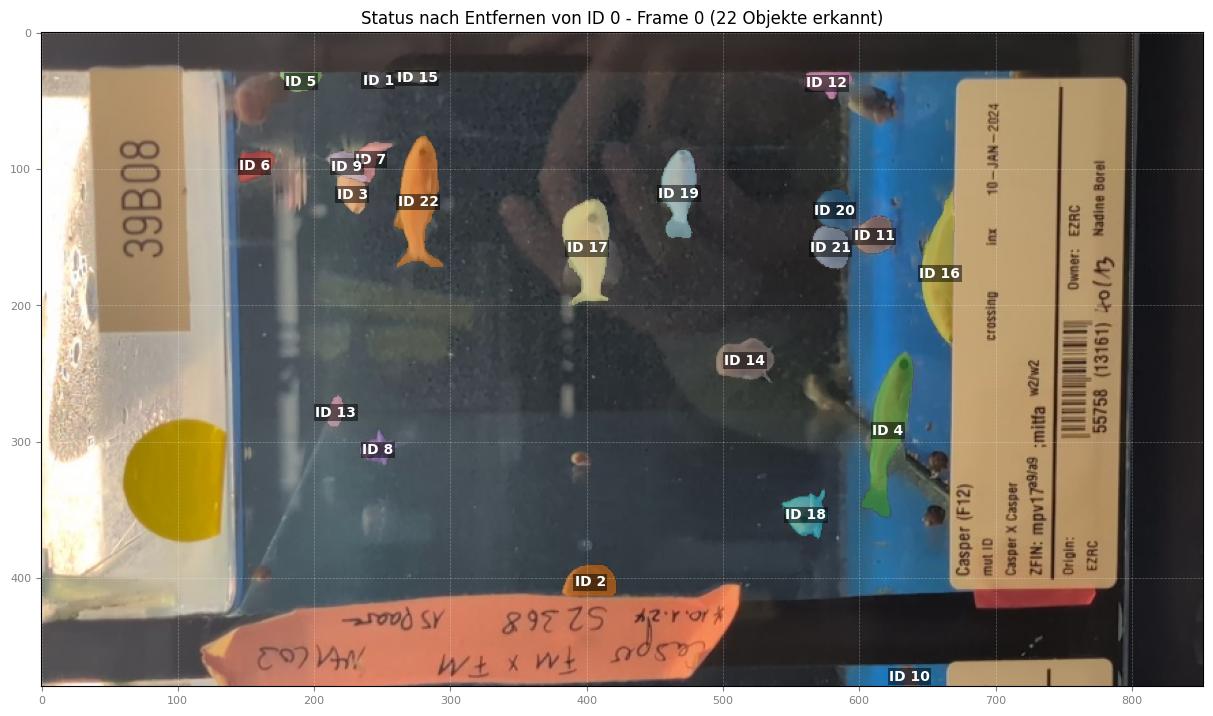

In [23]:
obj_id_to_remove = 0

# need_output=True gibt uns die aktualisierten Masken für die betroffenen Frames zurück
new_obj_ids, updated_frames = predictor2.remove_object(
    inference_state=inference_state2, 
    obj_id=obj_id_to_remove, 
    need_output=True
)

ann_frame_idx = 0 
current_masks = None

for f_idx, masks in updated_frames:
    if f_idx == ann_frame_idx:
        current_masks = masks
        break

visualize_current_state(
    frame_idx = ann_frame_idx,
    masks = current_masks,
    obj_ids = new_obj_ids, # Die neue ID-Liste ohne die 0
    video_frames = video_frames,
    title = f"Status nach Entfernen von ID {obj_id_to_remove}"
)

Now we propagate the new state

In [24]:
video_segments={}
for frame_idx, obj_ids, low_res_masks, video_res_masks, obj_scores in predictor2.propagate_in_video(
    inference_state2, 
    start_frame_idx=0, 
    max_frame_num_to_track=2, 
    reverse=False, 
    propagate_preflight=True,
):
    print(f"Bearbeite Frame {frame_idx}...")
    
    # DER FIX: Wir loopen über die 'obj_ids' vom Tracker, NICHT über die alten Listen
    video_segments[frame_idx] = {
        out_obj_id: (video_res_masks[i] > 0.0).cpu().numpy()
        for i, out_obj_id in enumerate(obj_ids)
    }

propagate in video:   0%|          | 0/3 [00:00<?, ?it/s]

Bearbeite Frame 0...
Bearbeite Frame 1...
Bearbeite Frame 2...


NameError: name 'gc' is not defined

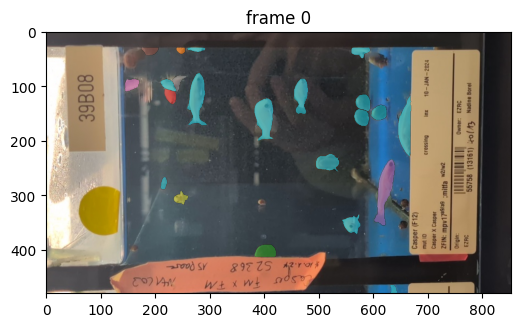

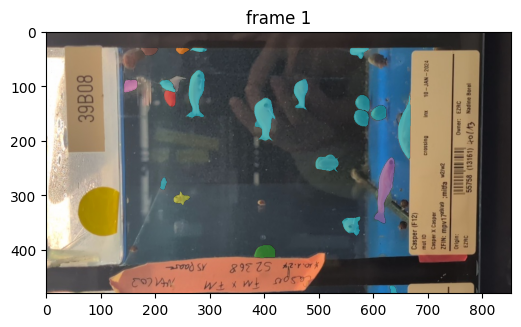

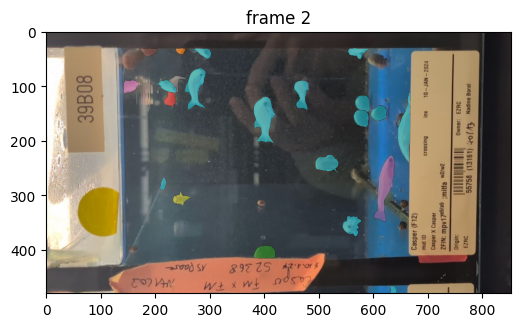

In [25]:
vis_frame_stride = 1
plt.close("all")
for out_frame_idx in range(0, 3, vis_frame_stride):
    plt.figure(figsize=(6, 4))
    plt.title(f"frame {out_frame_idx}")
    plt.imshow(video_frames[out_frame_idx])
    for out_obj_id, out_mask in video_segments[out_frame_idx].items():
        show_mask(out_mask, plt.gca(), obj_id=out_obj_id)

In [28]:
video_segments={}
for frame_idx, obj_ids, low_res_masks, video_res_masks, obj_scores in predictor2.propagate_in_video(
    inference_state2, 
    start_frame_idx=2, 
    max_frame_num_to_track=2, 
    reverse=False, 
    propagate_preflight=False
):
    print(f"Bearbeite Frame {frame_idx}...")
    
    # DER FIX: Wir loopen über die 'obj_ids' vom Tracker, NICHT über die alten Listen
    video_segments[frame_idx] = {
        out_obj_id: (video_res_masks[i] > 0.0).cpu().numpy()
        for i, out_obj_id in enumerate(obj_ids)
    }
gc.collect()
torch.cuda.empty_cache()

propagate in video:   0%|          | 0/3 [00:00<?, ?it/s]

Bearbeite Frame 2...


OutOfMemoryError: CUDA out of memory. Tried to allocate 6.61 GiB. GPU 0 has a total capacity of 8.00 GiB of which 0 bytes is free. Including non-PyTorch memory, this process has 17179869184.00 GiB memory in use. Of the allocated memory 15.90 GiB is allocated by PyTorch, and 5.58 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)